In [ ]:
# =====================================================================
# Object-level analysis: SAR sensor comparison at the DAM (buffer) scale
# =====================================================================
# Robustness check on the SPATIAL UNIT of the main pixel-level comparison.
# Same pipeline (Random Forest + 2 km spatial block CV + threshold-independent
# metrics), but the unit of analysis is the dam, represented by a 30 m circular
# neighbourhood, with SAR backscatter aggregated per buffer (mean / median / SD).
# This is an EXTENSION; it does not replace the pixel-level main model.


# =====================================================================
# 0. SETUP
# =====================================================================

# We import the libraries that we are going to use in this project as well as any other tools.
# All the libraries were retrieved from the CASA's Computer Environment. #DOCUMENT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree
import os

# Methodology: We will use a Random Forest Classifier to predict the presence of beaver dams. The model will be trained on a dataset of known dam locations and their corresponding SAR data, and then tested on a separate dataset to evaluate its performance.
from sklearn.ensemble import RandomForestClassifier


# Pipeline and preprocessing
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             cohen_kappa_score, roc_auc_score, average_precision_score)

# We install the required libraries for spatial analysis. The `esda` library is used for exploratory spatial data analysis, and `libpysal` is a library for spatial data science. These libraries provide tools for analyzing spatial patterns and relationships in the data.
#!pip install esda libpysal

from libpysal.weights import DistanceBand, w_difference
from esda.moran import Moran


# We set a random seed for reproducibility of results. This ensures that the random processes in the code (like data splitting) produce the same results each time the code is run.
SEED = 17
np.random.seed(SEED)

# We set the working directory.
os.chdir('/home/jovyan/work/Desktop/R/UCL/Dissertation/dissertation_scripts/')

# We set the buffer size in meters that will be applied around every dam in GEE when sampling negatives. This buffer is used to avoid sampling negative points too close to known dam locations, which could lead to biased model training and evaluation.
BUFFER_M = 30    # buffer applied around every dam in GEE when sampling negatives


In [2]:
# =====================================================================
# 1. DATA PRESENTATION
# =====================================================================

# We set the path to the data file.
PATH_DATA = "data/rf_objects_dataset.csv"

# We upload our data
obj = pd.read_csv(PATH_DATA)

# We rename our variable class into "dam".
obj = obj.rename(columns={'class': 'dam'})

print("=== OBJECT-LEVEL DATASET ===")
print(f"Our dataset has {obj.shape[0]:,} rows and {obj.shape[1]} columns.")
print("Columns:", list(obj.columns))
print("\nClass balance:"); print(obj['dam'].value_counts())

=== OBJECT-LEVEL DATASET ===
Our dataset has 142,443 rows and 21 columns.
Columns: ['dam', 'x', 'y', 's1_VV_mean', 's1_VV_median', 's1_VV_stdDev', 's1_VH_mean', 's1_VH_median', 's1_VH_stdDev', 's1_ratio_mean', 's1_ratio_median', 's1_ratio_stdDev', 'sao_HH_mean', 'sao_HH_median', 'sao_HH_stdDev', 'sao_HV_mean', 'sao_HV_median', 'sao_HV_stdDev', 'sao_ratio_mean', 'sao_ratio_median', 'sao_ratio_stdDev']

Class balance:
dam
0    114205
1     28238
Name: count, dtype: int64


In [3]:
# Let's have a quick look to it
obj.head()

,dam,x,y,s1_VV_mean,s1_VV_median,s1_VV_stdDev,s1_VH_mean,s1_VH_median,s1_VH_stdDev,s1_ratio_mean,...,s1_ratio_stdDev,sao_HH_mean,sao_HH_median,sao_HH_stdDev,sao_HV_mean,sao_HV_median,sao_HV_stdDev,sao_ratio_mean,sao_ratio_median,sao_ratio_stdDev
0,0,607235.043646,3.935075e+06,-2.117602,-1.945337,1.525119,-13.612405,-13.447238,0.828315,11.494803,...,1.710261,-1.021717,-1.383731,1.209878,-8.634922,-8.543928,0.544451,7.613206,7.306846,0.949664
1,0,607645.057533,3.935405e+06,-13.454975,-13.544016,0.762950,-23.205085,-23.583621,1.677170,9.750110,...,2.301893,-10.047675,-9.955729,0.549704,-24.486925,-23.232729,3.196278,14.439250,13.388409,3.613734
2,0,607314.961609,3.935115e+06,-1.545882,-2.099689,1.115142,-13.014163,-13.158449,1.016939,11.468281,...,1.635383,-3.165728,-2.817427,1.309714,-10.414834,-9.746121,1.301110,7.249106,7.206645,0.615868
3,0,607194.836458,3.935015e+06,-0.035192,-0.758733,2.138648,-12.862036,-12.760483,1.001337,12.826843,...,2.422070,-1.256827,-1.152849,0.385125,-8.126310,-8.192636,0.526847,6.869483,6.899550,0.487860
4,0,607584.994972,3.935235e+06,-11.073228,-11.035160,1.178648,-19.574126,-19.437273,0.772887,8.500898,...,1.489585,-8.600027,-8.668019,0.888519,-19.436350,-19.086932,2.898043,10.836323,10.292334,3.139904


In [4]:
# Lets's see our missing values.
obj.isna().sum().sort_values(ascending=False)

dam                 0
x                   0
y                   0
s1_VV_mean          0
s1_VV_median        0
s1_VV_stdDev        0
s1_VH_mean          0
s1_VH_median        0
s1_VH_stdDev        0
s1_ratio_mean       0
s1_ratio_median     0
s1_ratio_stdDev     0
sao_HH_mean         0
sao_HH_median       0
sao_HH_stdDev       0
sao_HV_mean         0
sao_HV_median       0
sao_HV_stdDev       0
sao_ratio_mean      0
sao_ratio_median    0
sao_ratio_stdDev    0
dtype: int64

In [5]:
# Our dataset has no missing values in none of its features.

# Now, let's have a look to our target variable, `dam`.
# If `dam` == 1, there is a beaver's dam
# If `dam` == 0, there is not a beaver's dam

obj['dam'].value_counts()

dam
0    114205
1     28238
Name: count, dtype: int64

In [6]:
# We arrange data into a features matrix and target vector 
STATS = ['mean', 'median', 'stdDev']

# SENTINEL-1
FEATURES_S1_OBJ  = [f's1_{b}_{s}'  for b in ['VV', 'VH', 'ratio'] for s in STATS]
# SAOCOM
FEATURES_SAO_OBJ = [f'sao_{b}_{s}' for b in ['HH', 'HV', 'ratio'] for s in STATS]
# Environmental context
FEATURES_CONTEXT = ['npp', 'slope', 'elevation']

# Combine into the full feature list
FEATURES_OBJ = FEATURES_S1_OBJ + FEATURES_SAO_OBJ

In [7]:
# We run a quick exploratory data analysis to understand the distribution of our features and their relationship with the target variable.
# Class balance
print("=== CLASS BALANCE ===")
print(obj['dam'].value_counts())
print(f"Positive rate: {obj['dam'].mean():.1%}")
 
# Have a look to our bounding box
print("\n=== COORDINATES ===")
print(f"x/y NaN: {obj['x'].isna().sum()} / {obj['y'].isna().sum()}  (expected 0)")
print(f"x: {obj['x'].min():,.0f} to {obj['x'].max():,.0f}")
print(f"y: {obj['y'].min():,.0f} to {obj['y'].max():,.0f}")
print("Exact (x,y) duplicates:", obj.duplicated(subset=['x', 'y']).sum())

# Let's build a summary of our variables.
for stat in ['mean', 'median', 'stdDev']:
    cols = [c for c in FEATURES_OBJ if c.endswith(f'_{stat}')]
    print(f"\n=== FEATURE RANGES -- {stat} ===")
    print(obj[cols].describe(percentiles=[.05, .5, .95]).T.round(3))

=== CLASS BALANCE ===
dam
0    114205
1     28238
Name: count, dtype: int64
Positive rate: 19.8%

=== COORDINATES ===
x/y NaN: 0 / 0  (expected 0)
x: 589,065 to 666,825
y: 3,926,075 to 3,985,925
Exact (x,y) duplicates: 345

=== FEATURE RANGES -- mean ===
                   count    mean    std     min      5%     50%     95%  \
s1_VV_mean      142443.0 -11.197  2.436 -27.041 -14.913 -11.255  -7.335   
s1_VH_mean      142443.0 -18.809  3.147 -42.179 -24.298 -18.618 -14.232   
s1_ratio_mean   142443.0   7.612  2.046   1.199   4.789   7.305  11.449   
sao_HH_mean     142443.0  -4.593  1.465 -13.396  -7.065  -4.526  -2.403   
sao_HV_mean     142443.0  -8.668  2.574 -31.978 -12.989  -8.154  -5.475   
sao_ratio_mean  142443.0   4.075  1.627   0.130   2.197   3.727   6.704   

                   max  
s1_VV_mean      12.389  
s1_VH_mean       1.064  
s1_ratio_mean   23.594  
sao_HH_mean      6.823  
sao_HV_mean     -0.184  
sao_ratio_mean  22.021  

=== FEATURE RANGES -- median ===
          

In [8]:
# We remove duplicate objects.
before = len(obj)
obj = obj.drop_duplicates().reset_index(drop=True)

In [9]:
# We compute some additional features that will be used in the modelling phase. These features are derived from the spatial relationships of the pixels to known dam locations and help to provide context for the model.

# (a) dist_to_dam: distance to the nearest known dam.
#     Reference = the in-ROI inventory dams present in the dataset (class==1).
dam_xy = obj.loc[obj['dam'] == 1, ['x', 'y']].values
tree = cKDTree(dam_xy)
# For a positive, the nearest neighbour is itself (dist 0). In that case, we take the 2nd nearest neighbour (k=2).
dist, _ = tree.query(obj[['x', 'y']].values, k=2)
obj['dist_to_dam'] = np.where(obj['dam'] == 1, dist[:, 1], dist[:, 0])

# For a negative, the 1st neighbour is already a real dam.
neg_dist = obj.loc[obj['dam'] == 0, 'dist_to_dam']
print("\n=== dist_to_dam (negatives, object level) ===")
print(f"min={neg_dist.min():.1f}  p5={neg_dist.quantile(.05):.1f}  "
      f"p50={neg_dist.quantile(.5):.1f}  p95={neg_dist.quantile(.95):.1f}  max={neg_dist.max():.1f}")
print(f"negatives closer than {BUFFER_OBJ} m to a dam: {(neg_dist < BUFFER_OBJ).sum():,}")

BUFFER_OBJ = 60   # m, centre-to-centre. 60 m = 2x the 30 m buffer radius, so the
                  # negative and dam sampling windows do not physically overlap
                  # (a negative closer than this would aggregate pixels belonging to
                  # a real dam). Stricter than the pixel-level 30 m, which is
                  # appropriate because objects have spatial extent that points lack.

# Enforce an exact 30 m buffer: drop the few negatives that the rasterised
# GEE buffer left between MIN_NEG_DIST and the pixel-grid edge.
before = len(obj)
obj = obj[~((obj['dam'] == 0) & (obj['dist_to_dam'] < BUFFER_OBJ))].reset_index(drop=True)
print(f"Negatives dropped by {BUFFER_OBJ} m buffer: {before - len(obj):,} | remaining: {len(obj):,}")

# --- Modelling frame summary ---
print("\n=== OBJECT MODELLING FRAME READY ===")
print(f"Total: {len(obj):,} | positives: {(obj['dam']==1).sum():,} | "
      f"negatives: {(obj['dam']==0).sum():,}")
print(f"Ratio pos:neg = 1:{(obj['dam']==0).sum()/(obj['dam']==1).sum():.1f}")

# Drop the auxiliary column so it never leaks into the feature matrix.
obj = obj.drop(columns=['dist_to_dam'])



=== dist_to_dam (negatives, object level) ===
min=22.2  p5=58.3  p50=313.8  p95=1164.3  max=3670.0


NameError: name 'BUFFER_OBJ' is not defined

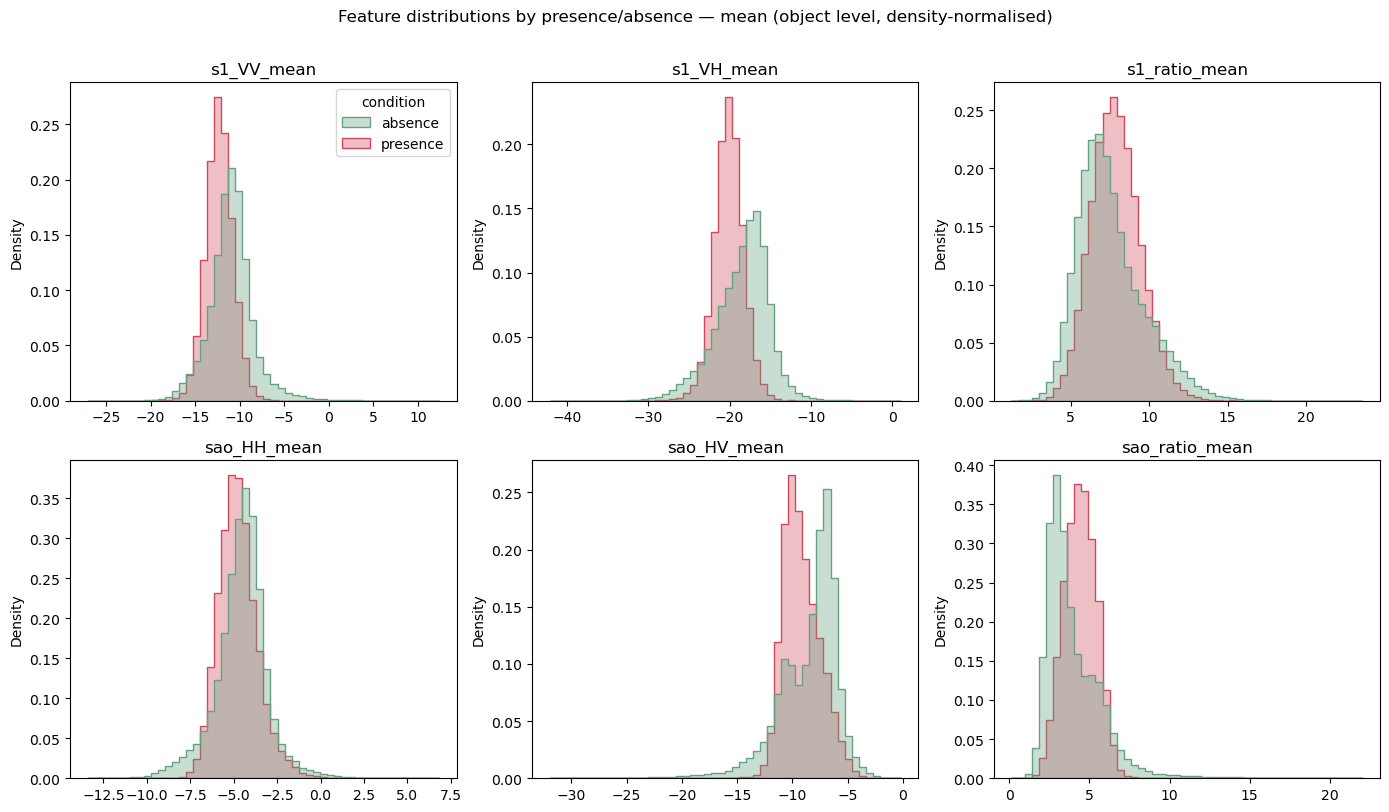

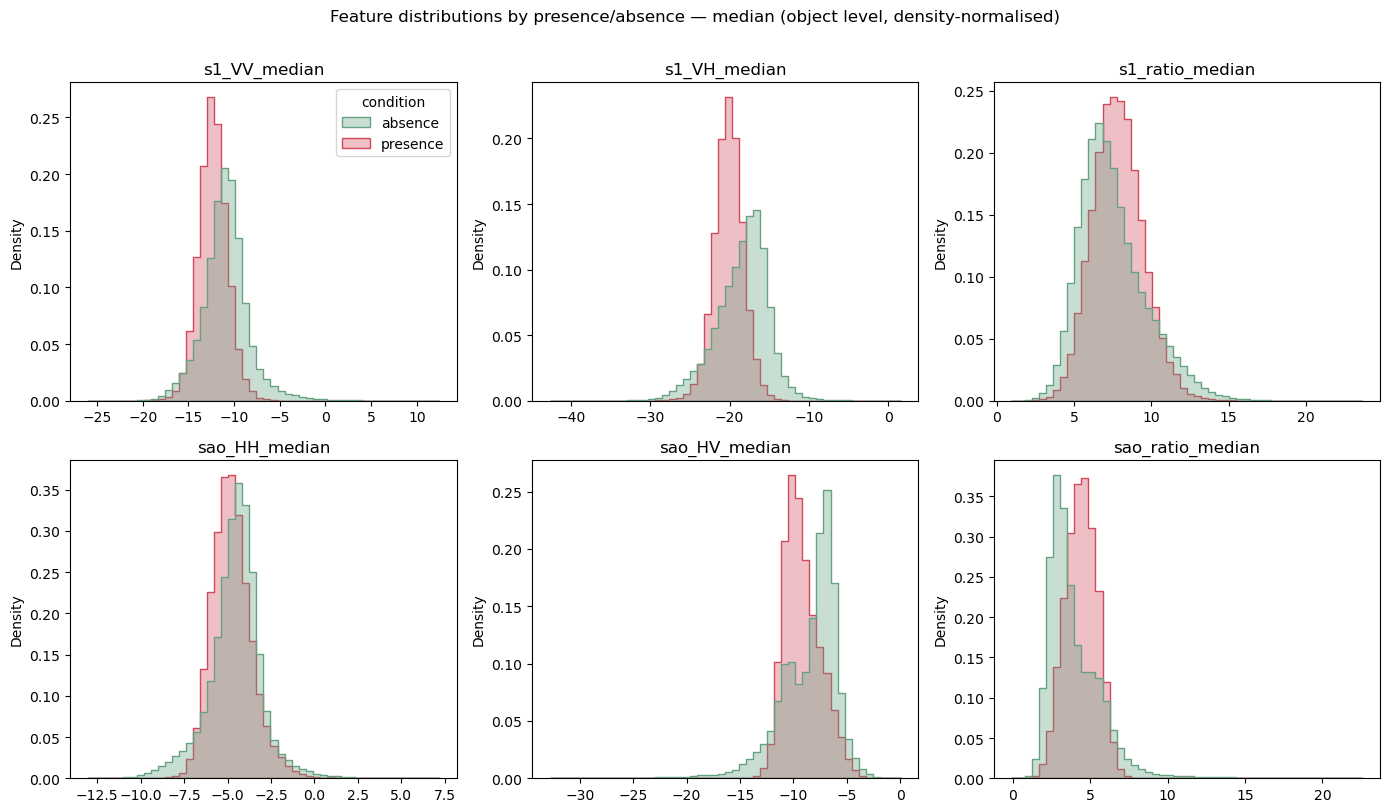

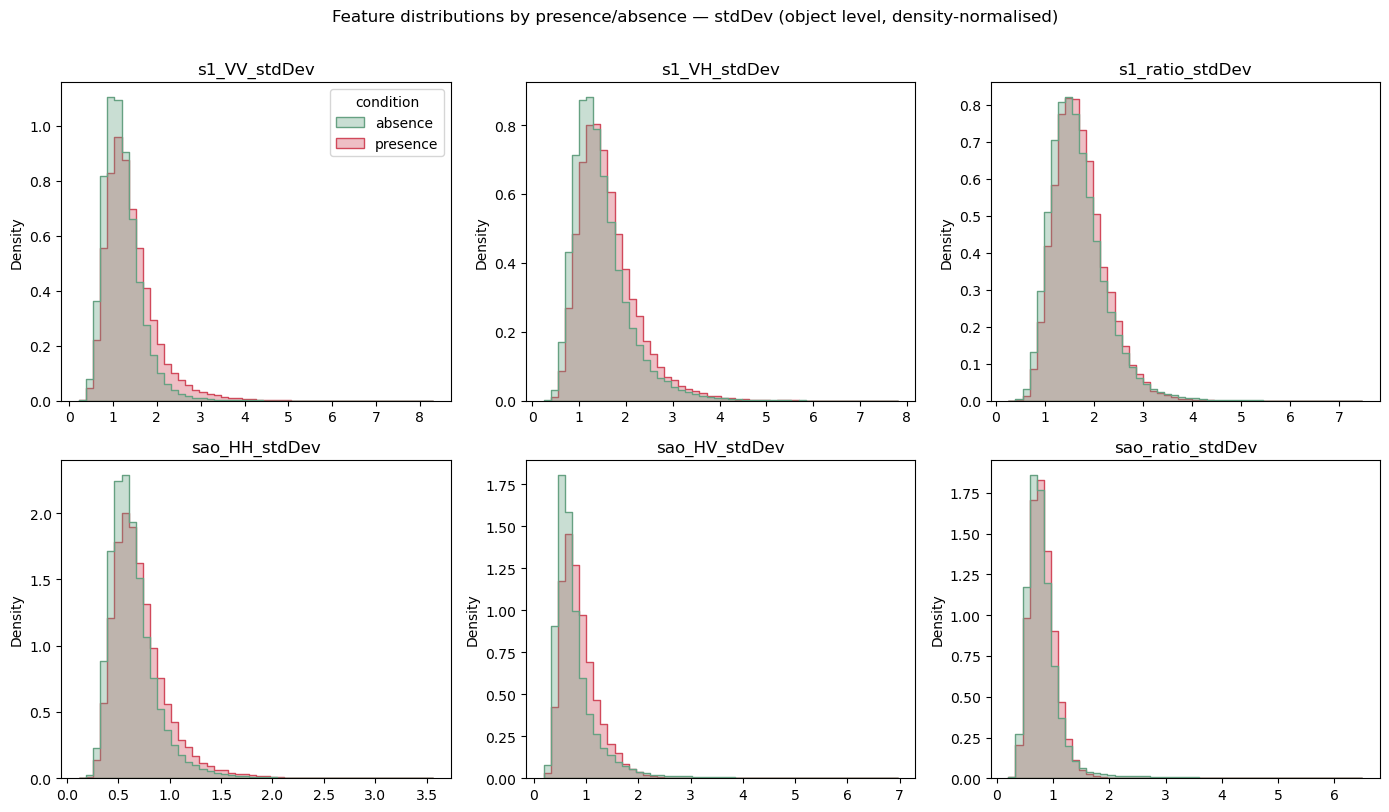

In [ ]:
# We set up the labels and color palette for the plots.
LABELS  = {1: 'presence', 0: 'absence'}
PALETTE = {'presence': '#d1495b', 'absence': '#66a182'}

# Temporary display column (text) just for plotting; the model still uses dam 1/0
plot_df = obj.copy()
plot_df['condition'] = plot_df['dam'].map(LABELS)

# One figure per statistic (mean / median / stdDev), 6 SAR bands each
for stat in ['mean', 'median', 'stdDev']:
    feats = [f for f in FEATURES_OBJ if f.endswith(f'_{stat}')]
    ncols = 3
    nrows = int(np.ceil(len(feats) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten()

    for i, feat in enumerate(feats):
        sns.histplot(data=plot_df, x=feat, hue='condition',
                     stat='density', common_norm=False,   # normalise EACH group so shapes are comparable
                     bins=50, element='step', fill=True, alpha=0.35,
                     palette=PALETTE, ax=axes[i], legend=(i == 0))
        axes[i].set_title(feat)
        axes[i].set_xlabel('')

    for j in range(len(feats), len(axes)):   # hide unused panels
        axes[j].axis('off')

    fig.suptitle(f'Feature distributions by presence/absence — {stat} (object level, density-normalised)', y=1.01)
    fig.tight_layout()
    plt.show()

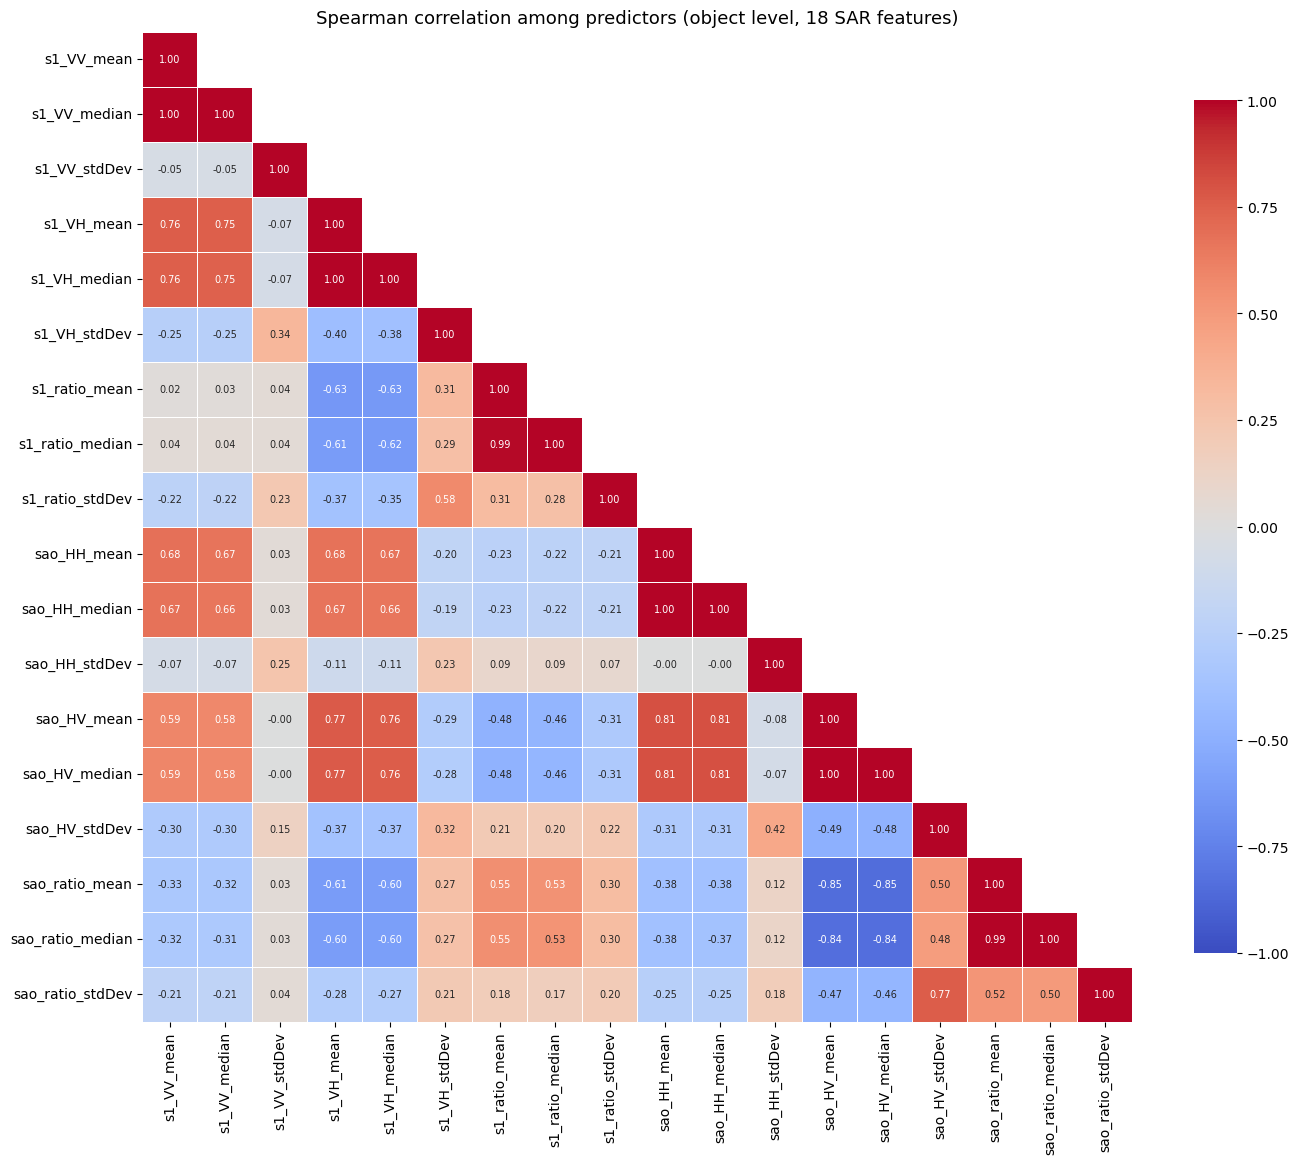

In [ ]:
# Spearman correlation matrix (redundancy check, object level: S1 vs SAOCOM aggregates)
corr = obj[FEATURES_OBJ].corr(method='pearson')

# Mask the upper triangle -> read it once, no mirror-image clutter
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Plot heatmap (18x18 -> larger figure, smaller annotations)
plt.figure(figsize=(14, 12))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
plt.title("Spearman correlation among predictors (object level, 18 SAR features)", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# We drop the median which is redundant with mean.
STATS_KEEP = ['mean', 'stdDev']

# SENTINEL-1
FEATURES_S1_OBJ  = [f's1_{b}_{s}'  for b in ['VV','VH','ratio'] for s in STATS_KEEP]
# SAOCOM
FEATURES_SAO_OBJ = [f'sao_{b}_{s}' for b in ['HH','HV','ratio'] for s in STATS_KEEP]

# Combine into the full feature list
FEATURES_OBJ = FEATURES_S1_OBJ + FEATURES_SAO_OBJ   # 12 features

print(f"Object-level features ({len(FEATURES_OBJ)}):", FEATURES_OBJ)

Object-level features (12): ['s1_VV_mean', 's1_VV_stdDev', 's1_VH_mean', 's1_VH_stdDev', 's1_ratio_mean', 's1_ratio_stdDev', 'sao_HH_mean', 'sao_HH_stdDev', 'sao_HV_mean', 'sao_HV_stdDev', 'sao_ratio_mean', 'sao_ratio_stdDev']


In [ ]:
# =====================================================================
# 2. METHODOLOGY
# =====================================================================

# We define a reusable helper function used to summarize model performance  across the three models.
def summarize_performance(label, y_true, y_pred, y_proba):
    """Key classification metrics for BOTH classes.
    Accuracy is omitted due to the deliberate class balance in training."""
    return {
        'model':         label,
        'recall_dam':    recall_score(y_true, y_pred, pos_label=1),
        'recall_bg':     recall_score(y_true, y_pred, pos_label=0),
        'precision_dam': precision_score(y_true, y_pred, pos_label=1),
        'f1_dam':        f1_score(y_true, y_pred, pos_label=1),
        'kappa':         cohen_kappa_score(y_true, y_pred),
        'roc_auc':       roc_auc_score(y_true, y_proba),
        'pr_auc':        average_precision_score(y_true, y_proba),
    }


In [ ]:
SUB_N = min(5000, len(obj))
sub = obj.sample(n=SUB_N, random_state=SEED).reset_index(drop=True)
coords = sub[['x', 'y']].values
# use the MEAN features (the level signal); SD is a different dimension
sar_feats_obj = [f for f in FEATURES_OBJ if f.endswith('_mean')]
edges = [0, 250, 500, 750, 1000, 1500, 2000, 2500, 3000, 4000, 5000]

print(f"Moran's I ring-based correlogram (OBJECT level), subsample n={SUB_N}")
header = "ring (m)      | " + " ".join(f"{f.split('_',1)[1]:>10}" for f in sar_feats_obj) + " |  mean"
print(header); print("-" * len(header))

for i in range(1, len(edges)):
    d_lo, d_hi = edges[i-1], edges[i]
    w_hi = DistanceBand(coords, threshold=d_hi, binary=True, silence_warnings=True)
    w_ring = w_hi if d_lo == 0 else w_difference(
        w_hi, DistanceBand(coords, threshold=d_lo, binary=True, silence_warnings=True),
        constrained=False, silence_warnings=True)
    w_ring.transform = 'r'
    Is, cells = [], []
    for f in sar_feats_obj:
        try:
            mi = Moran(sub[f].values, w_ring, permutations=99)
            mark = "" if mi.p_sim < 0.05 else "*"
            cells.append(f"{mi.I:+.2f}{mark:>1}"); Is.append(mi.I)
        except Exception:
            cells.append("      n/a")
    mean_I = np.mean(Is) if Is else float('nan')
    print(f"{d_lo:>4}-{d_hi:<5}   | " + " ".join(f"{c:>10}" for c in cells) + f" | {mean_I:+.2f}")

print("\n(* = p >= 0.05, not significant in that ring)")

Moran's I ring-based correlogram (OBJECT level), subsample n=5000
ring (m)      |    VV_mean    VH_mean ratio_mean    HH_mean    HV_mean ratio_mean |  mean
-----------------------------------------------------------------------------------------
   0-250     |     +0.49      +0.54      +0.35      +0.56      +0.63      +0.60  | +0.53
 250-500     |     +0.34      +0.36      +0.26      +0.31      +0.46      +0.48  | +0.37
 500-750     |     +0.29      +0.29      +0.16      +0.24      +0.42      +0.46  | +0.31
 750-1000    |     +0.18      +0.21      +0.14      +0.15      +0.32      +0.35  | +0.22
1000-1500    |     +0.12      +0.17      +0.11      +0.10      +0.28      +0.30  | +0.18
1500-2000    |     +0.09      +0.13      +0.08      +0.08      +0.23      +0.24  | +0.14
2000-2500    |     +0.08      +0.12      +0.07      +0.07      +0.20      +0.22  | +0.13
2500-3000    |     +0.09      +0.10      +0.05      +0.06      +0.17      +0.19  | +0.11
3000-4000    |     +0.09      +0.10      +

In [ ]:
# We set the block size for spatial cross-validation. The block size is set to 2 km, which is the same as the pixel-level analysis.
BLOCK_KM = 2.0   
print(f"\nBLOCK_KM set to {BLOCK_KM} (object-level correlogram: elbow ~1.5-2 km, plateau beyond)")

bs = BLOCK_KM * 1000                              

# We map each object's centre coordinate to its grid-cell index.
# Combining the column and row indices gives a unique cell label ("col_row").
# All objects falling in the same 2x2 km cell share the same block_id, so they
# are always kept together (train OR test) -> removes spatial leakage between folds.
obj['block_id'] = ((obj['x'] // bs).astype(int).astype(str) + '_' +
                   (obj['y'] // bs).astype(int).astype(str))

# Are there enough blocks (with dams) for a stable k-fold CV?
n_blocks   = obj['block_id'].nunique()                              # total non-empty blocks
dam_blocks = obj.loc[obj['dam'] == 1, 'block_id'].nunique()        # blocks containing >=1 dam
per_block_dams = obj[obj['dam'] == 1].groupby('block_id').size()   # dams per (dam-containing) block

print(f"BLOCK_KM={BLOCK_KM}: {n_blocks} non-empty blocks, {dam_blocks} with >=1 dam")
print(f"dams per block (of those with dams): min={per_block_dams.min()}, "
      f"median={int(per_block_dams.median())}, max={per_block_dams.max()}")



BLOCK_KM set to 2.0 (object-level correlogram: elbow ~1.5-2 km, plateau beyond)
BLOCK_KM=2.0: 716 non-empty blocks, 638 with >=1 dam
dams per block (of those with dams): min=1, median=32, max=262


In [ ]:

N_SPLITS = 5


def run_rf_spatial(df, features, label, n_splits=N_SPLITS):
    """Block spatial CV on `df`. Pooled out-of-fold metrics + per-fold mean/SD.
    Parametrised by dataframe (no global `pixels`) so it is safe in a standalone script."""
    X = df[features].values
    y = df['dam'].values
    groups = df['block_id'].values

    gkf = GroupKFold(n_splits=n_splits)
    oof_true, oof_pred, oof_proba, per_fold = [], [], [], []

    for tr_idx, te_idx in gkf.split(X, y, groups):
        rf = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                    random_state=SEED, n_jobs=-1)
        rf.fit(X[tr_idx], y[tr_idx])
        yt, yp = y[te_idx], rf.predict(X[te_idx])
        ypr = rf.predict_proba(X[te_idx])[:, 1]
        oof_true.append(yt); oof_pred.append(yp); oof_proba.append(ypr)
        per_fold.append({'roc_auc': roc_auc_score(yt, ypr),
                         'pr_auc':  average_precision_score(yt, ypr)})

    y_true  = np.concatenate(oof_true)
    y_pred  = np.concatenate(oof_pred)
    y_proba = np.concatenate(oof_proba)
    m = summarize_performance(label, y_true, y_pred, y_proba)

    pf = pd.DataFrame(per_fold)
    m['roc_auc_sd'] = pf['roc_auc'].std()
    m['pr_auc_sd']  = pf['pr_auc'].std()
    return m, (y_true, y_pred, y_proba), pf


NameError: name 'summarise_performance' is not defined

In [ ]:
# =====================================================================
# 3. OBJECT-LEVEL COMPARISON (S1 vs SAOCOM vs both, spatial CV)
# =====================================================================
results_obj = []
m_s1_o,   _, _ = run_rf_spatial(obj, FEATURES_S1_OBJ,  "S1 only (object)")
m_sao_o,  _, _ = run_rf_spatial(obj, FEATURES_SAO_OBJ, "SAOCOM only (object)")
m_both_o, _, _ = run_rf_spatial(obj, FEATURES_OBJ,     "S1 + SAOCOM (object)")
results_obj.extend([m_s1_o, m_sao_o, m_both_o])


cols = ['model', 'roc_auc', 'roc_auc_sd', 'pr_auc', 'pr_auc_sd', 'recall_dam', 'recall_bg']
print("\n=== OBJECT-LEVEL COMPARISON (2 km spatial block CV) ===")
print(pd.DataFrame(results_obj)[cols].round(3).to_string(index=False))


=== OBJECT-LEVEL COMPARISON (2 km spatial block CV) ===
               model  roc_auc  roc_auc_sd  pr_auc  pr_auc_sd  recall_dam  recall_bg
    S1 only (object)    0.796       0.008   0.435      0.017       0.191      0.953
SAOCOM only (object)    0.791       0.007   0.429      0.016       0.184      0.954
S1 + SAOCOM (object)    0.868       0.008   0.581      0.018       0.374      0.948


In [ ]:
# --- Object level with MEANS ONLY (6 features) -> fair 6-vs-6 comparison with pixel ---
# Isolates the effect of the analysis UNIT (pixel vs object) from the effect of
# the extra SD features. run_rf_spatial is already defined above (reused as-is).
F_S1_MEAN  = [f's1_{b}_mean'  for b in ['VV', 'VH', 'ratio']]
F_SAO_MEAN = [f'sao_{b}_mean' for b in ['HH', 'HV', 'ratio']]

results_obj_mean = []
m_s1_m,   _, _ = run_rf_spatial(obj, F_S1_MEAN,               "S1 only (object, mean)")
m_sao_m,  _, _ = run_rf_spatial(obj, F_SAO_MEAN,             "SAOCOM only (object, mean)")
m_both_m, _, _ = run_rf_spatial(obj, F_S1_MEAN + F_SAO_MEAN, "S1 + SAOCOM (object, mean)")
results_obj_mean.extend([m_s1_m, m_sao_m, m_both_m])

cols = ['model', 'roc_auc', 'roc_auc_sd', 'pr_auc', 'pr_auc_sd', 'recall_dam', 'recall_bg']
print("=== OBJECT-LEVEL, MEANS ONLY (6 features, comparable to pixel) ===")
print(pd.DataFrame(results_obj_mean)[cols].round(3).to_string(index=False))

=== OBJECT-LEVEL, MEANS ONLY (6 features, comparable to pixel) ===
                     model  roc_auc  roc_auc_sd  pr_auc  pr_auc_sd  recall_dam  recall_bg
    S1 only (object, mean)    0.742       0.005   0.364      0.011       0.246      0.912
SAOCOM only (object, mean)    0.711       0.007   0.334      0.014       0.208      0.915
S1 + SAOCOM (object, mean)    0.836       0.009   0.515      0.022       0.351      0.935


In [34]:
def tss_threshold(y_true, y_proba, thresholds=np.arange(0.05, 0.96, 0.05), label=""):
    rows = []
    for t in thresholds:
        yp = (y_proba >= t).astype(int)
        tp = np.sum((yp==1)&(y_true==1)); fn = np.sum((yp==0)&(y_true==1))
        tn = np.sum((yp==0)&(y_true==0)); fp = np.sum((yp==1)&(y_true==0))
        sens = tp/(tp+fn); spec = tn/(tn+fp)
        rows.append((round(t,2), sens, spec, sens+spec-1))
    tab = pd.DataFrame(rows, columns=['threshold','sensitivity','specificity','TSS'])
    best = tab.loc[tab['TSS'].idxmax()]
    print(f"\n=== TSS sweep: {label} ===")
    print(tab.round(3).to_string(index=False))
    print(f"\nOptimal threshold = {best['threshold']:.2f} (TSS={best['TSS']:.3f}, "
          f"sens={best['sensitivity']:.3f}, spec={best['specificity']:.3f})")
    return float(best['threshold'])

# --- Re-run the combined object model capturing OOF predictions ---
m_both_o, pred_both_o, _ = run_rf_spatial(obj, FEATURES_OBJ, "S1 + SAOCOM (object)")

y_true_o, _, y_proba_o = pred_both_o
best_t_obj = tss_threshold(y_true_o, y_proba_o, label="S1 + SAOCOM (object, spatial CV)")

print("\n=== object level: 0.50 vs TSS-optimal ===")
for t in [0.50, best_t_obj]:
    yp = (y_proba_o >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_o, yp).ravel()
    print(f"threshold={t:.2f} -> recall_dam={tp/(tp+fn):.3f} "
          f"recall_bg={tn/(tn+fp):.3f} precision_dam={tp/(tp+fp):.3f}")


=== TSS sweep: S1 + SAOCOM (object, spatial CV) ===
 threshold  sensitivity  specificity   TSS
      0.05        0.975        0.484 0.459
      0.10        0.942        0.601 0.543
      0.15        0.897        0.683 0.580
      0.20        0.847        0.742 0.589
      0.25        0.782        0.793 0.574
      0.30        0.710        0.836 0.546
      0.35        0.628        0.873 0.501
      0.40        0.548        0.902 0.450
      0.45        0.462        0.926 0.388
      0.50        0.377        0.947 0.324
      0.55        0.294        0.964 0.257
      0.60        0.212        0.977 0.189
      0.65        0.145        0.985 0.130
      0.70        0.086        0.992 0.078
      0.75        0.040        0.997 0.037
      0.80        0.015        0.999 0.014
      0.85        0.002        1.000 0.002
      0.90        0.000        1.000 0.000
      0.95        0.000        1.000 0.000

Optimal threshold = 0.20 (TSS=0.589, sens=0.847, spec=0.742)

=== object level: 0.50 v